# Smart Irrigation Water Recommendation System

## Project Objective

This project develops an end-to-end machine learning system for predicting recommended irrigation amounts using meteorological and agricultural data.

The workflow includes:

- Exploratory Data Analysis
- Feature Engineering
- Time-based validation
- Regression modeling
- Model evaluation
- Model serialization
- API deployment with FastAPI
- Docker containerization
- AWS deployment using Amazon ECR and EC2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import joblib

## 2. Data Loading and Initial Inspection

The dataset contains historical meteorological and irrigation observations used to analyze and predict irrigation requirements.

In [4]:
df = pd.read_csv(
    r"C:\Users\djato\Downloads\peerj-cs-10-2112-s002.csv",
    encoding="gb18030"
)

df.head()

,Date,Air pressure on the ground(hPa),Average temperatures(℃),Maximum temperature(℃),Minimum temperature(℃),Precipitation(mm),Relative humidity(%),Wind velocity(m/s),Hours of sunshine(h),ET0,Water demand,Amount of irrigation
0,20000501,987.28,13.12,17.59,7.63,2.79,72.19,2.34,5.73,2.9,2.8,-1.572
1,20000502,986.12,15.74,22.07,10.07,0.01,48.44,2.40,6.56,4.3,2.3,1.796
2,20000503,983.99,16.94,23.85,7.75,0.02,47.92,3.87,6.37,5.2,2.2,2.164
3,20000504,984.64,17.41,25.61,6.89,0.21,45.99,4.58,6.09,5.9,2.7,2.268
4,20000505,994.32,6.72,9.55,2.66,0.15,71.44,3.76,2.94,2.1,3.3,0.732


In [5]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (3519, 12)

Missing values:
Date                               0
Air pressure on the ground(hPa)    0
Average temperatures(℃)            0
Maximum temperature(℃)             0
Minimum temperature(℃)             0
Precipitation(mm)                  0
Relative humidity(%)               0
Wind velocity(m/s)                 0
Hours of sunshine(h)               0
ET0                                0
Water demand                       0
Amount of irrigation               0
dtype: int64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3519 entries, 0 to 3518
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             3519 non-null   int64  
 1   Air pressure on the ground(hPa)  3519 non-null   float64
 2   Average temperatures(℃)          3519 non-null   float64
 3   Maximum temperature(℃)           3519 non-null   float64
 4   Minimum temperature(℃)           3519 non-null   float64
 5   Precipitation(mm)                3519 non-null   float64
 6   Relative humidity(%)             3519 non-null   float64
 7   Wind velocity(m/s)               3519 non-null   float64
 8   Hours of sunshine(h)             3519 non-null   float64
 9   ET0                              3519 non-null   float64
 10  Water demand                     3519 non-null   float64
 11  Amount of irrigation             3519 non-null   float64
dtypes: float64(11), int64(1)
memory

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Date,3519.0,2.011072e+07,66342.073443,2.000050e+07,2.005082e+07,2.011072e+07,2.017061e+07,2.022093e+07
Air pressure on the ground(hPa),3519.0,9.838134e+02,5.768900,9.588900e+02,9.799800e+02,9.834900e+02,9.875900e+02,1.004310e+03
Average temperatures(℃),3519.0,2.015737e+01,4.513302,1.690000e+00,1.713000e+01,2.079000e+01,2.365000e+01,3.170000e+01
Maximum temperature(℃),3519.0,2.513038e+01,4.543661,6.670000e+00,2.227000e+01,2.568000e+01,2.841000e+01,3.805000e+01
Minimum temperature(℃),3519.0,1.557350e+01,5.010635,-2.350000e+00,1.198500e+01,1.632000e+01,1.951000e+01,2.686000e+01
Precipitation(mm),3519.0,3.668832e+00,8.161180,0.000000e+00,0.000000e+00,4.100000e-01,3.410000e+00,1.219600e+02
Relative humidity(%),3519.0,6.590134e+01,16.623382,1.374000e+01,5.559500e+01,6.872000e+01,7.845000e+01,9.838000e+01
Wind velocity(m/s),3519.0,3.390665e+00,1.398816,6.700000e-01,2.340000e+00,3.140000e+00,4.220000e+00,9.970000e+00
Hours of sunshine(h),3519.0,5.189065e+00,1.653993,2.200000e-01,4.170000e+00,5.400000e+00,6.460000e+00,8.230000e+00
ET0,3519.0,4.241944e+00,1.546219,1.000000e+00,3.200000e+00,4.000000e+00,4.950000e+00,1.370000e+01


### Initial Data Quality Assessment

The dataset contains 3,519 observations and 12 variables covering meteorological conditions, evapotranspiration, water demand, and irrigation.

No missing values were identified. Descriptive statistics were examined to identify unusual values and understand the distribution of the numerical variables.

## 3. Target Engineering

The original `Amount of irrigation` variable contains negative values. In an operational irrigation recommendation system, negative irrigation is not actionable because a farmer cannot apply a negative quantity of water.

Therefore, a new operational target called `Recommended_Irrigation_mm` is created by setting negative irrigation values to zero.

The original variable is preserved for scientific reference but is excluded from the model features to prevent target leakage.

In [8]:
negative_count = (df["Amount of irrigation"] < 0).sum()
negative_percentage = (df["Amount of irrigation"] < 0).mean() * 100

print("Negative irrigation values:", negative_count)
print(f"Percentage: {negative_percentage:.2f}%")

Negative irrigation values: 917
Percentage: 26.06%


In [9]:
df["Recommended_Irrigation_mm"] = df["Amount of irrigation"].clip(lower=0)

df["Recommended_Irrigation_mm"].describe()

count    3519.000000
mean        2.552136
std         2.149155
min         0.000000
25%         0.000000
50%         2.460800
75%         4.206500
max        12.236000
Name: Recommended_Irrigation_mm, dtype: float64

## 4. Exploratory Data Analysis

Exploratory Data Analysis is used to understand how environmental variables relate to recommended irrigation requirements.

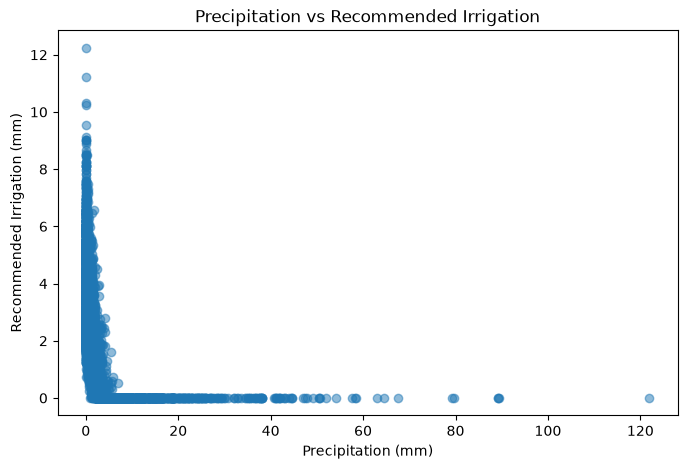

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Precipitation(mm)"],
    df["Recommended_Irrigation_mm"],
    alpha=0.5
)

plt.xlabel("Precipitation (mm)")
plt.ylabel("Recommended Irrigation (mm)")
plt.title("Precipitation vs Recommended Irrigation")
plt.show()

Higher precipitation is generally associated with lower irrigation requirements. At low precipitation levels, irrigation requirements vary considerably, indicating that additional environmental variables influence irrigation demand.

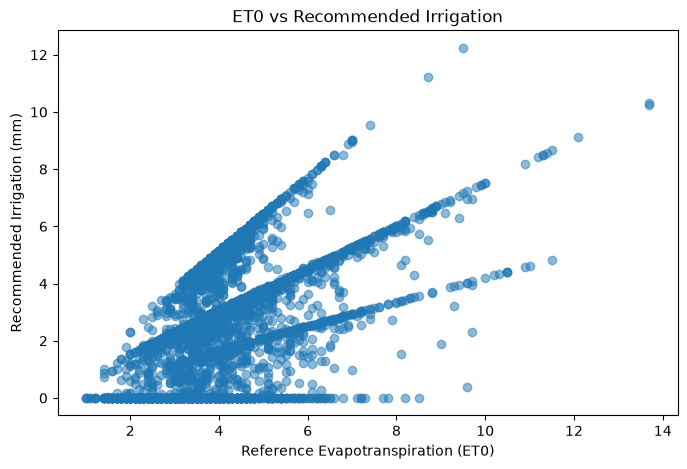

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["ET0"],
    df["Recommended_Irrigation_mm"],
    alpha=0.5
)

plt.xlabel("Reference Evapotranspiration (ET0)")
plt.ylabel("Recommended Irrigation (mm)")
plt.title("ET0 vs Recommended Irrigation")
plt.show()

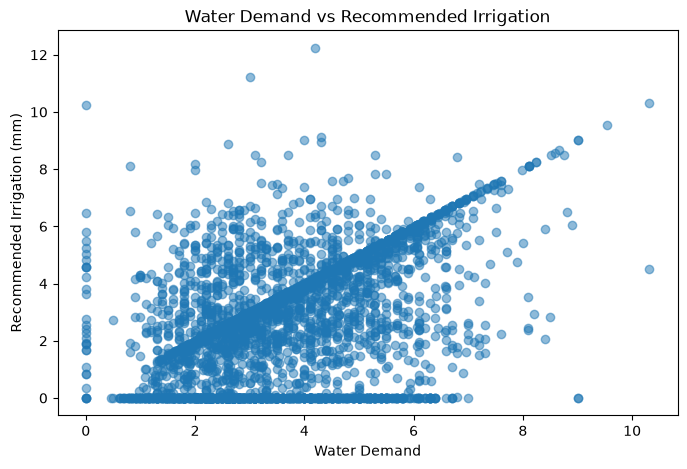

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Water demand"],
    df["Recommended_Irrigation_mm"],
    alpha=0.5
)

plt.xlabel("Water Demand")
plt.ylabel("Recommended Irrigation (mm)")
plt.title("Water Demand vs Recommended Irrigation")
plt.show()

In [14]:
corr = df.corr(numeric_only=True)

corr["Recommended_Irrigation_mm"].sort_values(
    ascending=False
)

Recommended_Irrigation_mm          1.000000
Hours of sunshine(h)               0.616791
Amount of irrigation               0.601742
ET0                                0.572462
Maximum temperature(℃)             0.502830
Water demand                       0.426462
Average temperatures(℃)            0.425031
Minimum temperature(℃)             0.272850
Air pressure on the ground(hPa)    0.074654
Wind velocity(m/s)                 0.045363
Date                              -0.049710
Relative humidity(%)              -0.418279
Precipitation(mm)                 -0.489604
Name: Recommended_Irrigation_mm, dtype: float64

The exploratory analysis indicates that precipitation, temperature, sunshine duration, ET0, humidity, and water demand contain useful predictive information.

Correlation values describe linear associations and should not be interpreted as causal effects.

## 5. Temporal Feature Engineering

Because irrigation requirements vary throughout the agricultural season, temporal information is extracted from the observation date.

In [15]:
df["Date"] = pd.to_datetime(
    df["Date"].astype(str),
    format="%Y%m%d"
)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_year"] = df["Date"].dt.dayofyear

df[["Date", "Year", "Month", "Day", "Day_of_year"]].head()

,Date,Year,Month,Day,Day_of_year
0,2000-05-01,2000,5,1,122
1,2000-05-02,2000,5,2,123
2,2000-05-03,2000,5,3,124
3,2000-05-04,2000,5,4,125
4,2000-05-05,2000,5,5,126


## 6. Feature Selection

The model uses meteorological, evapotranspiration, water-demand, and temporal variables.

`Amount of irrigation` is intentionally excluded because the operational target `Recommended_Irrigation_mm` was derived directly from it. Including it would create target leakage.

In [16]:
features = [
    "Air pressure on the ground(hPa)",
    "Average temperatures(℃)",
    "Maximum temperature(℃)",
    "Minimum temperature(℃)",
    "Precipitation(mm)",
    "Relative humidity(%)",
    "Wind velocity(m/s)",
    "Hours of sunshine(h)",
    "ET0",
    "Water demand",
    "Month",
    "Day_of_year"
]

X = df[features]
y = df["Recommended_Irrigation_mm"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3519, 12)
y shape: (3519,)


## 7. Temporal Train-Test Split

A chronological train-test split is used instead of a random split because the observations are time-dependent.

The model is trained using observations from 2000–2020 and evaluated on future observations from 2021–2022.

In [17]:
train_mask = df["Year"] <= 2020
test_mask = df["Year"] >= 2021

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print(
    "Training years:",
    df.loc[train_mask, "Year"].min(),
    "-",
    df.loc[train_mask, "Year"].max()
)

print(
    "Testing years:",
    df.loc[test_mask, "Year"].min(),
    "-",
    df.loc[test_mask, "Year"].max()
)

Training shape: (3213, 12)
Test shape: (306, 12)
Training years: 2000 - 2020
Testing years: 2021 - 2022


In [18]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(name)
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 8. Baseline Model

A baseline model predicting the average training irrigation requirement is used as a reference. Machine-learning models should substantially outperform this baseline.

In [19]:
baseline_value = y_train.mean()

y_pred_baseline = np.full(
    len(y_test),
    baseline_value
)

baseline_results = evaluate_model(
    "Baseline",
    y_test,
    y_pred_baseline
)

Baseline
MAE:  1.721
RMSE: 2.022
R²:   -0.036


In [20]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

Linear Regression
MAE:  0.926
RMSE: 1.179
R²:   0.648


## 9. Machine Learning Models

Random Forest and Gradient Boosting are evaluated because irrigation requirements may depend on nonlinear relationships and interactions between environmental variables.

In [21]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
MAE:  0.124
RMSE: 0.241
R²:   0.985


In [22]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb
)

Gradient Boosting
MAE:  0.173
RMSE: 0.245
R²:   0.985


In [23]:
comparison = pd.DataFrame([
    baseline_results,
    linear_results,
    rf_results,
    gb_results
])

comparison

,Model,MAE,RMSE,R2
0,Baseline,1.720682,2.022469,-0.036129
1,Linear Regression,0.926031,1.179162,0.647794
2,Random Forest,0.124074,0.241282,0.985253
3,Gradient Boosting,0.173009,0.245300,0.984758


Random Forest provides the strongest overall performance. It substantially reduces prediction error relative to both the baseline and Linear Regression while capturing nonlinear relationships in the data.

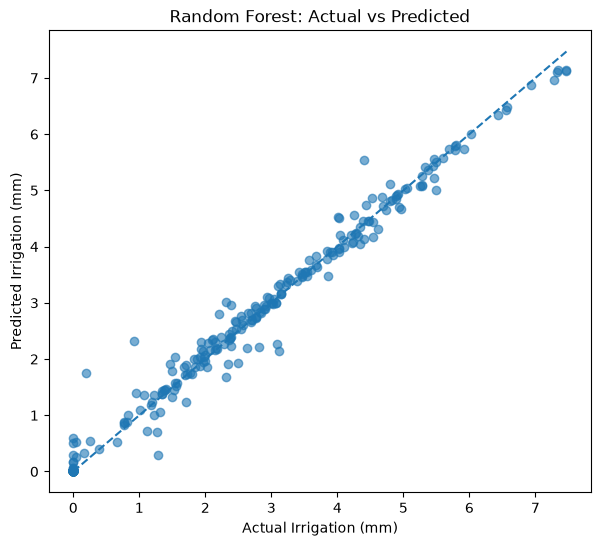

In [24]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

minimum = min(y_test.min(), y_pred_rf.min())
maximum = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Irrigation (mm)")
plt.ylabel("Predicted Irrigation (mm)")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [25]:
results = pd.DataFrame({
    "Actual_Irrigation_mm": y_test.values,
    "Predicted_Irrigation_mm": y_pred_rf
})

results["Absolute_Error_mm"] = np.abs(
    results["Actual_Irrigation_mm"]
    - results["Predicted_Irrigation_mm"]
)

results.sort_values(
    "Absolute_Error_mm",
    ascending=False
).head(10)

,Actual_Irrigation_mm,Predicted_Irrigation_mm,Absolute_Error_mm
218,0.1855,1.745739,1.560239
13,0.9200,2.315738,1.395738
17,4.4100,5.534848,1.124848
269,1.2816,0.292109,0.989491
271,3.1152,2.140704,0.974496
270,3.0888,2.267267,0.821533
247,2.3104,3.017093,0.706693
231,2.3192,1.687461,0.631739
97,2.8144,2.216442,0.597958
217,0.0000,0.587821,0.587821


In [26]:
zero_results = results[
    results["Actual_Irrigation_mm"] == 0
]

print("Zero-irrigation cases:", len(zero_results))

print(
    "Mean prediction:",
    zero_results["Predicted_Irrigation_mm"].mean()
)

print(
    "Maximum prediction:",
    zero_results["Predicted_Irrigation_mm"].max()
)

Zero-irrigation cases: 93
Mean prediction: 0.02290571326164875
Maximum prediction: 0.5878206666666672


In [27]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Precipitation(mm),0.604698
2,Maximum temperature(℃),0.115901
1,Average temperatures(℃),0.100537
8,ET0,0.059812
11,Day_of_year,0.055481
9,Water demand,0.040723
6,Wind velocity(m/s),0.006431
7,Hours of sunshine(h),0.006111
5,Relative humidity(%),0.004313
0,Air pressure on the ground(hPa),0.002477


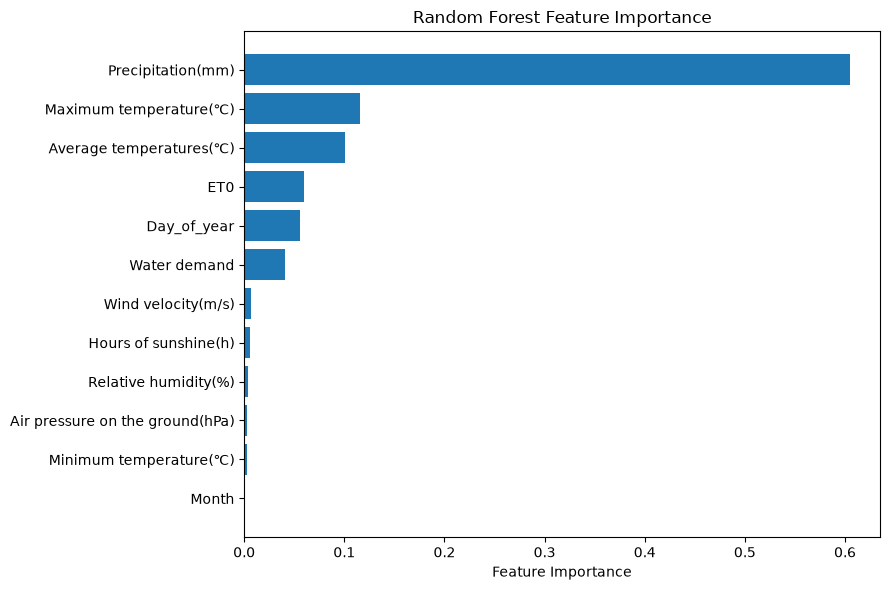

In [28]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

Precipitation is the most influential feature in the Random Forest model, followed by temperature-related variables, ET0, seasonal information, and water demand.

Feature importance represents the model's use of each variable and should not be interpreted as a causal percentage contribution.

## 10. Temporal Validation

Additional time-aware validation is performed to evaluate model stability across multiple historical periods rather than relying exclusively on the final 2021–2022 holdout set.

In [29]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (train_index, val_index) in enumerate(
    tscv.split(X),
    start=1
):
    X_cv_train = X.iloc[train_index]
    X_cv_val = X.iloc[val_index]

    y_cv_train = y.iloc[train_index]
    y_cv_val = y.iloc[val_index]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_cv_train, y_cv_train)

    pred = model.predict(X_cv_val)

    mae = mean_absolute_error(y_cv_val, pred)
    rmse = np.sqrt(
        mean_squared_error(y_cv_val, pred)
    )
    r2 = r2_score(y_cv_val, pred)

    cv_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Fold,MAE,RMSE,R2
0,1,0.326001,0.538787,0.938868
1,2,0.217422,0.424519,0.958079
2,3,0.150773,0.293159,0.980435
3,4,0.176149,0.391777,0.969939
4,5,0.125528,0.245231,0.986422


In [30]:

cv_results_df[["MAE", "RMSE", "R2"]].mean()

MAE     0.199174
RMSE    0.378695
R2      0.966749
dtype: float64

In [31]:
validation_periods = [
    (2015, 2016),
    (2017, 2018),
    (2019, 2020),
    (2021, 2022)
]

year_validation_results = []

for start_year, end_year in validation_periods:

    train = df["Year"] < start_year

    validation = (
        (df["Year"] >= start_year)
        & (df["Year"] <= end_year)
    )

    X_tr = X[train]
    y_tr = y[train]

    X_val = X[validation]
    y_val = y[validation]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)

    year_validation_results.append({
        "Validation Period":
            f"{start_year}-{end_year}",
        "MAE":
            mean_absolute_error(y_val, pred),
        "RMSE":
            np.sqrt(
                mean_squared_error(y_val, pred)
            ),
        "R2":
            r2_score(y_val, pred)
    })

year_validation_df = pd.DataFrame(
    year_validation_results
)

year_validation_df

,Validation Period,MAE,RMSE,R2
0,2015-2016,0.149593,0.336860,0.978208
1,2017-2018,0.182098,0.409812,0.964845
2,2019-2020,0.124468,0.247247,0.987891
3,2021-2022,0.124074,0.241282,0.985253


In [32]:
year_validation_df[
    ["MAE", "RMSE", "R2"]
].mean()

MAE     0.145058
RMSE    0.308800
R2      0.979049
dtype: float64

In [33]:
param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0]
}

search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

print(
    "Best CV MAE:",
    -search.best_score_
)

Best parameters:
{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
Best CV MAE: 0.20998688534045398


In [34]:
tuned_rf = search.best_estimator_

y_pred_tuned = tuned_rf.predict(X_test)

tuned_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_tuned
)

Tuned Random Forest
MAE:  0.123
RMSE: 0.242
R²:   0.985


## 11. Final Model Selection

Although hyperparameter tuning slightly improved MAE, the improvement over the original Random Forest was negligible and RMSE did not improve.

Therefore, the 300-tree Random Forest is retained as the final model because it provides excellent predictive performance with a simpler configuration.

Final held-out 2021–2022 performance:

- MAE: approximately 0.124 mm
- RMSE: approximately 0.241 mm
- R²: approximately 0.985

The R² value should not be interpreted as classification accuracy.

In [36]:
joblib.dump(
    rf_model,
    "../smart_irrigation_random_forest.joblib"
)

joblib.dump(
    features,
    "../smart_irrigation_features.joblib"
)

print("Final model and feature list saved.")

Final model and feature list saved.


In [37]:
loaded_model = joblib.load(
    "../smart_irrigation_random_forest.joblib"
)

loaded_features = joblib.load(
    "../smart_irrigation_features.joblib"
)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

recommended_irrigation = max(
    0,
    float(prediction)
)

actual = y_test.iloc[0]

print(
    f"Actual irrigation: {actual:.3f} mm"
)

print(
    f"Predicted irrigation: "
    f"{recommended_irrigation:.3f} mm"
)

print(
    f"Absolute error: "
    f"{abs(actual-recommended_irrigation):.3f} mm"
)

Actual irrigation: 1.344 mm
Predicted irrigation: 1.428 mm
Absolute error: 0.084 mm


## 12. Deployment

After model development and validation, the selected Random Forest model was deployed as a production-style REST API.

### Deployment Pipeline

Machine Learning Model  
→ Joblib Serialization  
→ FastAPI REST API  
→ Docker Container  
→ Amazon Elastic Container Registry (ECR)  
→ Amazon EC2  
→ Public Prediction Endpoint

The FastAPI application derives temporal features from the input date, constructs the expected model feature vector, performs inference, and returns a non-negative irrigation recommendation.

The Docker image was built locally, pushed to Amazon ECR, pulled by an EC2 instance using an IAM role, and executed as a containerized API.

## 13. Limitations

Despite strong validation performance, several limitations must be considered:

1. Model performance reflects the characteristics of this specific historical dataset and should not be interpreted as guaranteed field performance.

2. The operational irrigation target was derived by converting negative irrigation values to zero.

3. ET0 and water demand are available in the research dataset but would require reliable estimation or measurement in a real production environment.

4. The model has not yet been externally validated on farms in other geographic regions.

5. Soil characteristics, crop variety, crop growth stage, irrigation efficiency, and real-time soil moisture could further improve a production system.

Therefore, field validation would be required before using the model for real agricultural irrigation decisions.

## 14. Future Improvements

Future versions of the Smart Irrigation System could integrate:

- IoT soil-moisture sensors
- Temperature and humidity sensors
- Real-time weather data
- Rainfall forecasts
- Crop and soil information
- AWS IoT services
- Automated model inference
- SMS or mobile farmer notifications
- Power BI or Tableau dashboards
- CloudWatch monitoring
- HTTPS and custom domain
- CI/CD deployment
- Field validation and model retraining

The long-term objective is to transform the predictive model into a complete precision-agriculture decision-support platform.

## 15. Conclusion

This project demonstrates an end-to-end Machine Learning workflow for smart irrigation.

The project progressed from scientific data exploration and feature engineering to regression modeling, time-aware validation, model interpretation, API development, Docker containerization, and AWS deployment.

Among the evaluated models, Random Forest provided the strongest overall performance, achieving approximately MAE = 0.124 mm, RMSE = 0.241 mm, and R² = 0.985 on the held-out 2021–2022 period.

The project demonstrates how Data Science, Machine Learning, software engineering, and cloud technologies can be combined to build an operational precision-agriculture solution.